In [33]:
import cv2

import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

In [34]:
import os
print("Current working directory:", os.getcwd())
print("Files in current dir:", os.listdir())

Current working directory: C:\Users\udana\OneDrive\Documents\VC-CW\Garbage-Classification-CV
Files in current dir: ['.DS_Store', '.git', '.ipynb_checkpoints', 'anaconda_projects', 'bin', 'data', 'Garbage_Classification_CNN.ipynb', 'lib', 'pyvenv.cfg', 'share', 'test_imgs']


In [35]:

# Parameters
IMG_SIZE = 256
DATA_DIR = "./data"  # folder structure:
# ./data/plastic/*.jpg
# ./data/organic/*.jpg
# ./data/metal/*.jpg

CLASSES = ["plastic", "organic", "metal"]

# Lists to hold data and labels
X, y = [], []

# Loop through each class folder
for idx, category in enumerate(CLASSES):
    folder = os.path.join(DATA_DIR, category)
    for file in os.listdir(folder):
        img_path = os.path.join(folder, file)

        # Read image
        img = cv2.imread(img_path)
        if img is None:
            continue  # skip unreadable files

        # Step 1: Resize to fixed size (64x64)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        # Step 2: Normalize pixel values to [0,1]
        img = img / 255.0

        # Append to dataset
        X.append(img)
        y.append(idx)  # numeric label (0=plastic, 1=organic, 2=metal)

# Convert to numpy arrays
X = np.array(X, dtype="float32")
y = to_categorical(y, num_classes=len(CLASSES))  # one-hot encode labels

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Dataset shape:", X.shape)
print("Training set:", X_train.shape, y_train.shape)
print("Testing set:", X_test.shape, y_test.shape)

Dataset shape: (2325, 256, 256, 3)
Training set: (1860, 256, 256, 3) (1860, 3)
Testing set: (465, 256, 256, 3) (465, 3)


In [36]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [41]:
# Define CNN model (with Input layer)
model = models.Sequential([
    layers.Input(shape=(256, 256, 3)),       # <--- recommended way

    layers.Conv2D(16, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')   # 3 output classes
])

# Compile model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)                    │ (None, 254, 254, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 127, 127, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 125, 125, 32)        │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 62, 62, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 60, 60, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 57600)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │       7,372,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,396,899 (28.22 MB)

 Trainable params: 7,396,899 (28.22 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=7,            
    batch_size=32,
    verbose=1
)


Epoch 1/7
59/59 ━━━━━━━━━━━━━━━━━━━━ 27s 422ms/step - accuracy: 0.5590 - loss: 1.0047 - val_accuracy: 0.6796 - val_loss: 0.7958
Epoch 2/7
59/59 ━━━━━━━━━━━━━━━━━━━━ 24s 410ms/step - accuracy: 0.7393 - loss: 0.6346 - val_accuracy: 0.7075 - val_loss: 0.6640
Epoch 3/7
59/59 ━━━━━━━━━━━━━━━━━━━━ 25s 423ms/step - accuracy: 0.7828 - loss: 0.5222 - val_accuracy: 0.7226 - val_loss: 0.6883
Epoch 4/7
59/59 ━━━━━━━━━━━━━━━━━━━━ 24s 413ms/step - accuracy: 0.8069 - loss: 0.4708 - val_accuracy: 0.7677 - val_loss: 0.5729
Epoch 5/7
59/59 ━━━━━━━━━━━━━━━━━━━━ 25s 419ms/step - accuracy: 0.8513 - loss: 0.3799 - val_accuracy: 0.7699 - val_loss: 0.5814
Epoch 6/7
59/59 ━━━━━━━━━━━━━━━━━━━━ 24s 410ms/step - accuracy: 0.9014 - loss: 0.2600 - val_accuracy: 0.7591 - val_loss: 0.7201
Epoch 7/7
59/59 ━━━━━━━━━━━━━━━━━━━━ 24s 412ms/step - accuracy: 0.9430 - loss: 0.1877 - val_accuracy: 0.7785 - val_loss: 0.8535


In [43]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc*100:.2f}%")

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - accuracy: 0.7969 - loss: 0.7921
Test Accuracy: 77.85%


In [48]:
# Define class names (same order as Step 1)
CLASSES = ["plastic", "organic", "metal"]

def preprocess_image(img_path, img_size=256):
    # Load image with OpenCV
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Image not found: {img_path}")
    
    # Resize to CNN input size
    img = cv2.resize(img, (img_size, img_size))
    
    # Normalize to [0,1]
    img = img / 255.0
    
    # Add batch dimension (1,64,64,3)
    img = np.expand_dims(img, axis=0)
    return img

In [56]:
# Test image
test_img_path = "./test_imgs/bottle3.jpeg"

# Preprocess image
img_ready = preprocess_image(test_img_path)

# Predict
pred = model.predict(img_ready)
pred_class = np.argmax(pred, axis=1)[0]

print("Predicted class:", CLASSES[pred_class])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Predicted class: organic


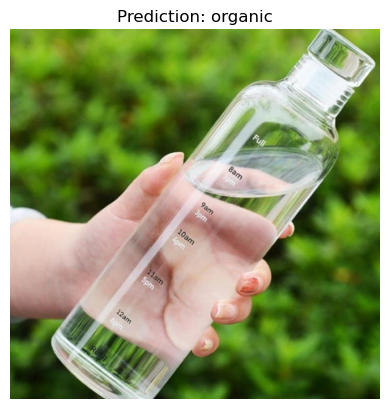

In [57]:
import matplotlib.pyplot as plt

img = cv2.imread(test_img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  

plt.imshow(img)
plt.title(f"Prediction: {CLASSES[pred_class]}")
plt.axis("off")
plt.show()
